## Домашнее задание № 1 (Макс. 10 баллов)

В данной домашней работе мы познакомимся на практике с пройденными темами, включающими в себя статистику, проверку гипотез и A/B тестирование.

### Задача 1 (2 балла)

**(1 Балл)** Рассчитайте среднее, стандартное отклонение и медиану по 1000 случайных выборок, порождённых нормальным распределением с $\mu = 5$ и $\sigma^2 = 4$, состоящих из 100 элементов. Постройте распределение полученных метрик.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sps
from tqdm import tqdm

def calc_stat_random_sample(mu=5, sigma=4, size=100):
    sample = np.random.normal(loc=mu, scale=np.sqrt(sigma), size=size)
    mean = sample.mean()
    std = sample.std(ddof=1)
    median = np.median(sample)
    return(mean, std, median)

n_samples = 1000

means = []
stds = []
medians = []

for i in range(n_samples):
    mean, std, median = calc_stat_random_sample()
    means.append(mean)
    stds.append(std)
    medians.append(median)

means = np.array(means)
stds = np.array(stds)
medians = np.array(medians)

In [2]:
import pandas as pd

results = pd.DataFrame({
    'mean': means,
    'std': stds,
    'median': medians
})

results.head(5)

,mean,std,median
0,4.805472,2.054370,4.971600
1,5.086310,2.124710,5.115328
2,5.133863,2.052401,4.959694
3,5.155086,2.177753,5.195859
4,5.071218,1.801230,5.134981


In [3]:
summary = pd.DataFrame({
    'metric': ['mean', 'std', 'median'],
    'mean_of_1000_samples': [means.mean(), stds.mean(), medians.mean()],
    'std_of_1000_samples': [means.std(), stds.std(), medians.std()]
})

summary

,metric,mean_of_1000_samples,std_of_1000_samples
0,mean,5.002210,0.201183
1,std,1.994227,0.139475
2,median,4.997503,0.250227


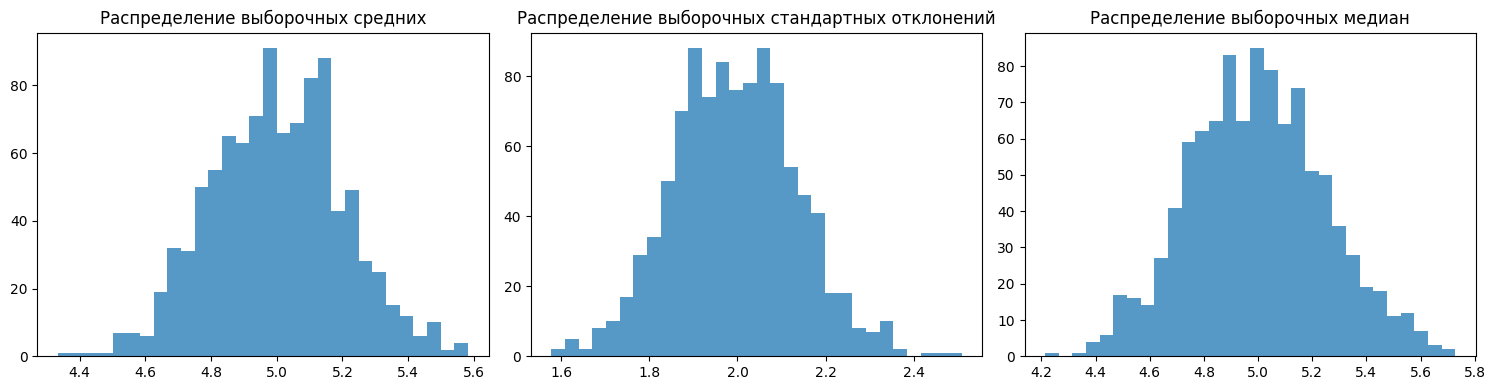

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(means, bins=30, alpha=0.75)
axes[0].set_title('Распределение выборочных средних')

axes[1].hist(stds, bins=30, alpha=0.75)
axes[1].set_title('Распределение выборочных стандартных отклонений')

axes[2].hist(medians, bins=30, alpha=0.75)
axes[2].set_title('Распределение выборочных медиан')

plt.tight_layout()
plt.show()

**(1 Балл)** Какому распределению принадлежит распределение средних? Почему?

Нормальному по ЦПТ

Так как среднее это сумма независимых случайных величин, делённая на n, а по центральной предельной теореме при достаточно большом n сумма будет стремится к нормальному распределению независимо от распределения исходных наблюдений. В этой задаче распределение изначально нормальное.

### Задача 2 (2 балла):

Оцените значение $\hat{\mu}$ параметра $\mu$ **(1 балл)** для нормального распределения $\mathscr{N}(\mu,1)$ используя метод максимального правдоподобия.

Справка: функция плотности распределения для нормального распределения имеет вид:
$$
    f(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \text{e}^{-\frac{(x - \mu)^2}{2 \sigma^2}}
$$

Функция правдоподобия:    L(μ) = ∏ᵢ f(xᵢ) = ∏ᵢ (1/√(2π)) · e^(−(xᵢ−μ)²/2)

Её логарифм:
ln L(μ) = −n/2 · ln(2π) − ½ Σᵢ(xᵢ−μ)²

Дифференцируем:
d/dμ ln L(μ) = Σᵢ(xᵢ−μ)

Ищем экстремум: 
Нужно приравнять к нулю Σᵢ(xᵢ−μ) = 0, откуда  μ̂ = (1/n) Σᵢ xᵢ = x̄

По сути, 2-ая производная ln L(μ) по μ = −n, т.е. она всегда отрицательна, тогда функция ln L(μ) будет вогнута, а найденная точка будет глобальным максимумом. 
И получается, что μ̂ = x̄ среднее арифметическое выборки будет значением μ, при котором наблюдаемые данные наиболее вероятные.

Сгенерируйте 1000 выборок размером 1000 наблюдений из нормального распределения с $\mu = 5, \sigma^2 = 1$, постройте распределение разности $\mu - \hat{\mu}$ и найдите среднее этой разности в зависимости от числа выборок **(1 балл)**.

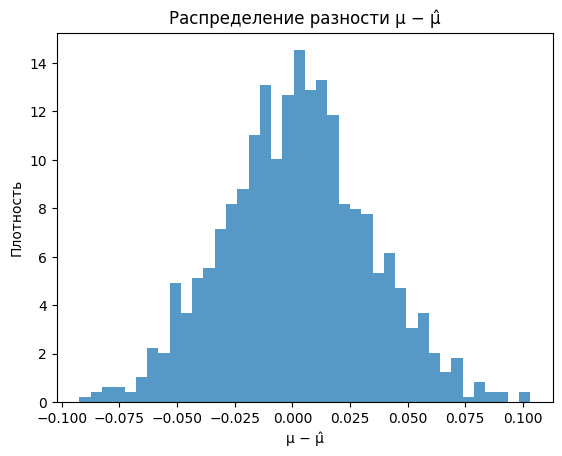

In [5]:
mu = 5
variance = 1
n_obs = 1000
n_samples = 1000

mu_array = np.array([
    np.random.normal(loc=mu, scale=np.sqrt(variance), size=n_obs).mean()
    for i in range(n_samples)
])

difference = mu - mu_array

plt.hist(difference, bins=40, density=True, alpha=0.75)
plt.xlabel('μ − μ̂')
plt.ylabel('Плотность')
plt.title('Распределение разности μ − μ̂')
plt.show()

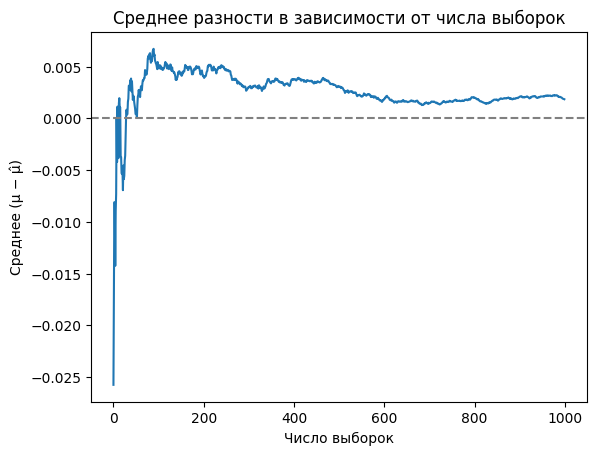

In [6]:
mean_diff = np.cumsum(difference) / np.arange(1, n_samples + 1)

plt.plot(mean_diff)
plt.axhline(0, linestyle='--', color='gray')
plt.xlabel('Число выборок')
plt.ylabel('Среднее (μ − μ̂)')
plt.title('Среднее разности в зависимости от числа выборок')
plt.show()

In [7]:
pd.DataFrame({
    'n_samples': [10, 100, 1000],
    'mean_diff': [mean_diff[9], mean_diff[99], mean_diff[-1]]
})

,n_samples,mean_diff
0,10,0.001146
1,100,0.004883
2,1000,0.001858


### Задача 3 (2 балла)

**(1 балл)** Пусть известно, что выборка в n наблюдений порождена распределением Бернулли ~Bernoulli(p), пусть среднее значение по выборке равно $\hat{p}$. Постройте формулу 95% доверительного интервал для среднего

Для 95% доверительного интервала по таблице z = 1.96, P(− 1.96 ≤ z ≤ 1.96) = 0.95

И тогда формула: p̂ ± 1.96 · √(p̂ (1 − p̂) / n) или же с 95% вероятностью p ∈ [ p̂ − 1.96 · √(p̂ (1 − p̂) / n) ; p̂ + 1.96 · √(p̂ (1 − p̂) / n) ]

**(1 балл)** Постройте 95% доверительный интервал на среднее в представленной выборке, используя бутстрап и сравните с теоретическим значением

In [8]:
X = sps.bernoulli.rvs(0.2, size = 10000, random_state=42)

p_hat = X.mean()
n = len(X)

z = 1.96
theor_str_e = np.sqrt(p_hat * (1 - p_hat) / n)
theor_c_intr = (p_hat - z * theor_str_e, p_hat + z * theor_str_e)

n_bootstrap = 10000
bootstrap_means = np.array([
    np.random.choice(X, size=n, replace=True).mean()
    for _ in range(n_bootstrap)
])

bootstrap_ci = np.percentile(bootstrap_means, [2.5, 97.5])

In [9]:
pd.DataFrame({
    'method': ['theoretical (Wald)', 'bootstrap'],
    'lower': [theor_c_intr[0], bootstrap_ci[0]],
    'upper': [theor_c_intr[1], bootstrap_ci[1]]
})

,method,lower,upper
0,theoretical (Wald),0.188416,0.203984
1,bootstrap,0.188400,0.204000


Теоретический интервал и бутстрап интервал получились достаточно близкими, [0.1884; 0.2039] и [0.1885; 0.204]. Такой результат получился скорее всего благодаря большой выборке (n = 10000)

### Задача 4 (4 балла)

Основным критерием для тестирования гипотезы о равенстве средних является t-test. Он строится на том, что по ЦПТ практически для любой случайной величины средние будут распределены нормально. 

В учебниках по статистике доказывается, что в силу этого для двух выборок, порождённых одинаково распределёнными независимыми случайными величинами с равным средним мы имеем асимпототику для выборочной t-статистики
$$
    T = \frac{\bar{x} - \bar{y}}{\sqrt{\frac{s_x^2}{n_1} + \frac{s_y^2}{n_2}}} \rightarrow t_{n_1 + n_2 - 2},
$$
где $\bar{x}, \bar{y}$ -- выборочные средние в выборках, $s_x^2, s_y^2$ -- выборочные дисперсии, $n_1, n_2$ -- размеры выборок, а $t_{n_1 + n_2 - 2}$ -- распределение Стьюдента с $n_1 + n_2 - 2$ степенями свободы.

**(1 балл)** Постройте плотность распределения Стьюдента с 1, 5, 10, 100 и 1000 степеней свободы, а также плотность стандартного нормального распределения

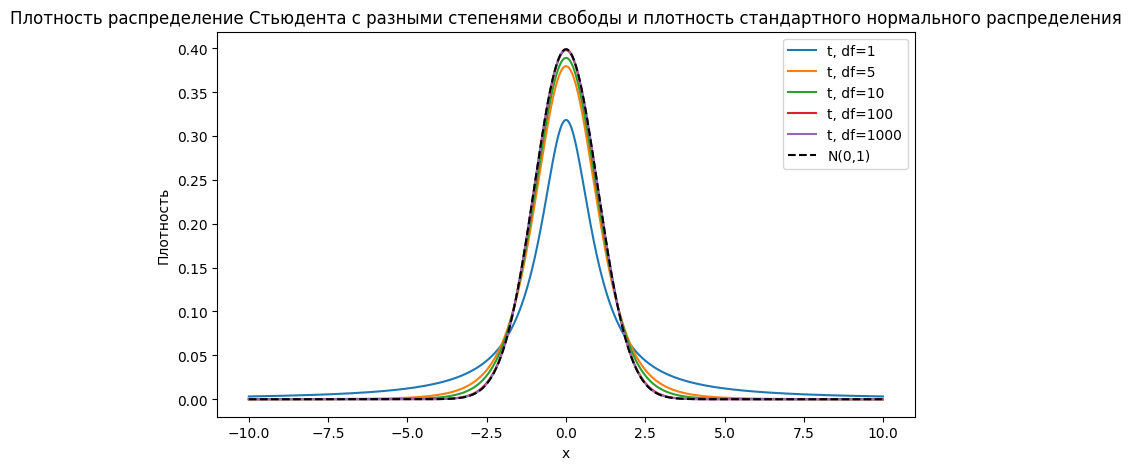

In [10]:
grid = np.arange(-10,10,0.01)

freedom_degrees = [1,5,10,100,1000]

plt.figure(figsize=(9, 5))
for df in freedom_degrees:
    plt.plot(grid, sps.t.pdf(grid, df=df), label=f't, df={df}')
plt.plot(grid, sps.norm.pdf(grid), label='N(0,1)', linestyle='--', color='black')
plt.xlabel('x')
plt.ylabel('Плотность')
plt.title('Плотность распределение Стьюдента с разными степенями свободы и плотность стандартного нормального распределения')
plt.legend()
plt.show()

**(1 балл)** Пусть нам необходимо запустить A/B тест: в первой группе мы оставляем кнопку в банковском приложении в сером цвете, во втором -- красим её в жёлтый. Всего у нас в месяц в приложение заходит 1000 различных клиентов. Базовая конверсия в нажатие кнопки сейчас составляет 0.2. Бизнес постановил, что MDE = 5%, то есть значимым будет считаться изменение, при котором конверсия будет больше 0.21 или меньше 0.19. Хватит ли нам данных, чтобы замерить эффект за один месяц при уровне значимости $\alpha = 0.05$, если мы планируем поделить выборку пополам на тест и контроль?

In [11]:
p1 = 0.2
p2_up = 0.21
p2_down = 0.19
alpha = 0.05
power_target = 0.8
flow = 1000
n_per_group_available = flow // 2

z_alpha = sps.norm.ppf(1 - alpha / 2)
z_beta = sps.norm.ppf(power_target)

def required_n(p1, p2):
    pooled_var = p1 * (1 - p1) + p2 * (1 - p2)
    return (z_alpha + z_beta) ** 2 * pooled_var / (p1 - p2) ** 2

n_need_up = required_n(p1, p2_up)
n_need_down = required_n(p1, p2_down)

pd.DataFrame({
    'Исходы': ['Исход 1', 'Исход 2'],
    'Сколько нужно наблюдений': [n_need_up, n_need_down],
    'Сколько есть наблюдений за один месяц': [n_per_group_available, n_per_group_available]
})

,Исходы,Сколько нужно наблюдений,Сколько есть наблюдений за один месяц
0,Исход 1,25579.499054,500
1,Исход 2,24637.633486,500


Как можно заметить, нужно около 25000 наблюдений на группу, а имеем только по 500 на группу в месяц. Получается, наших данных не хватит, их примерно в 50 раз меньше.

**(1 балл)** Мы провели тест и получили следующие результаты:

In [12]:
X_1, X_2 = sps.bernoulli.rvs(0.2, size = 1000, random_state=42), sps.bernoulli.rvs(0.21, size = 1000, random_state=42)

Можем ли мы утверждать на уровне значимости $\alpha = 0.05$, что эффект имел место быть?

In [13]:
p_value = sps.ttest_ind(X_2, X_1, equal_var=False).pvalue
p_value

np.float64(0.50650433746215)

Нет, нельзя утверждать на уровне значимости $\alpha = 0.05$, что эффект имел место быть. Так как (p-value) 0.507 > (α) 0.05, значит статистически значимого эффекта нет, Н0 не отвергается.

**(1 балл)** 

Что будет, если мы проведём 1000 таких тестов, "отпустив" random_state?

В какой доле случаев мы не задетектируем это существующее различие? Чему будет равна $\beta$?

In [24]:
# Под "отпущенным" random_state понимается None
# X_1, X_2 = sps.bernoulli.rvs(0.2, size = 1000), sps.bernoulli.rvs(0.21, size = 1000)

n_experiments = 1000
detected = []

for i in range(n_experiments):
    x1 = sps.bernoulli.rvs(0.2, size=1000)
    x2 = sps.bernoulli.rvs(0.21, size=1000)
    p = sps.ttest_ind(x2, x1, equal_var=False).pvalue
    detected.append(p < alpha)

detected = np.array(detected)
beta_empirical = 1 - detected.mean()

pd.DataFrame({
    'metric': ['power (доля задетектированных)', 'beta (доля недетекта)'],
    'value': [detected.mean(), beta_empirical]
})

,metric,value
0,power (доля задетектированных),0.092
1,beta (доля недетекта),0.908


Если отпустить random_state, тогда каждый раз будет генерироваться случайная выборка. А при фиксированном random_state = 42, 1000 раз был бы одинаковый результат, так как каждый раз пересоздавалась бы одна и та же последовательность случайных чисел.

Если доля задетектированных эффектов = 0.092, т.е. мощность всего 9.2 %, тогда доля не задетектируемых = 0.908, она же β = 0.908. 
Такая большая доля не задектируемых случаев понятна, так как по предыдущим подпунктам было видно, что данных в 50 раз меньше, чем нужно. И мощность низкая, так как в 90 % случаев не замечен эффект, который на самом деле есть.

А если различий не будет (при проведении 1000 A/A-тестов)? Как будет распределено p-value в этом случае?

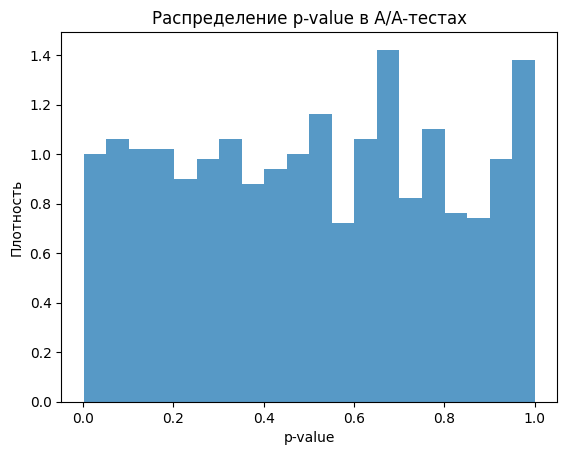

In [15]:
# Под A/A тестом имеем в виду: X_1, X_2 = sps.bernoulli.rvs(0.2, size = 1000), sps.bernoulli.rvs(0.2, size = 1000)

p_value_aa = []
for i in range(n_experiments):
    x1 = sps.bernoulli.rvs(0.2, size=1000)
    x2 = sps.bernoulli.rvs(0.2, size=1000)
    p = sps.ttest_ind(x2, x1, equal_var=False).pvalue
    p_value_aa.append(p)

p_value_aa = np.array(p_value_aa)

plt.hist(p_value_aa, bins=20, density=True, alpha=0.75)
plt.xlabel('p-value')
plt.ylabel('Плотность')
plt.title('Распределение p-value в A/A-тестах')
plt.show()

In [25]:
false_positive_rate = (p_value_aa < alpha).mean()
false_positive_rate

np.float64(0.048)

Если различий не будет, то p-value будет распределено равномерно на отрезке от 0 до 1. По гистограмме видно, что столбики примерно одной высоты везде. И ещё видно, что доля случаев, где p-value < 0.05 = 0.048 (по факту это ошибка 1 рода, ложноположительный эффект от теста), можно сказать, что сам тест ведёт себя корректно.